# Base model, with final QC

## mod hi vs mod lo

No cluster file specified for session 1
No cluster file specified for session 4
Session: 4 months post-surgery > pre-surgery, Cluster 1: PeakZ=5.47, MNI=[48.0, 30.0, 27.0], Mean ES=0.12%
Session: 4 months post-surgery > pre-surgery, Cluster 2: PeakZ=4.16, MNI=[36.0, -69.0, 42.0], Mean ES=0.09%
Session: 4 months post-surgery > pre-surgery, Cluster 3: PeakZ=5.06, MNI=[-42.0, -21.0, 60.0], Mean ES=-0.14%
Session: 4 months post-surgery > pre-surgery, Cluster 4: PeakZ=4.22, MNI=[27.0, 42.0, 33.0], Mean ES=0.09%
Session: 4 months post-surgery > pre-surgery, Cluster 5: PeakZ=4.42, MNI=[45.0, 42.0, -9.0], Mean ES=0.11%
Session: 12 months post-surgery > pre-surgery, Cluster 1: PeakZ=4.38, MNI=[-39.0, -21.0, 48.0], Mean ES=-0.12%


C:\Users\Patrick\AppData\Local\Temp\ipykernel_24864\237329469.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


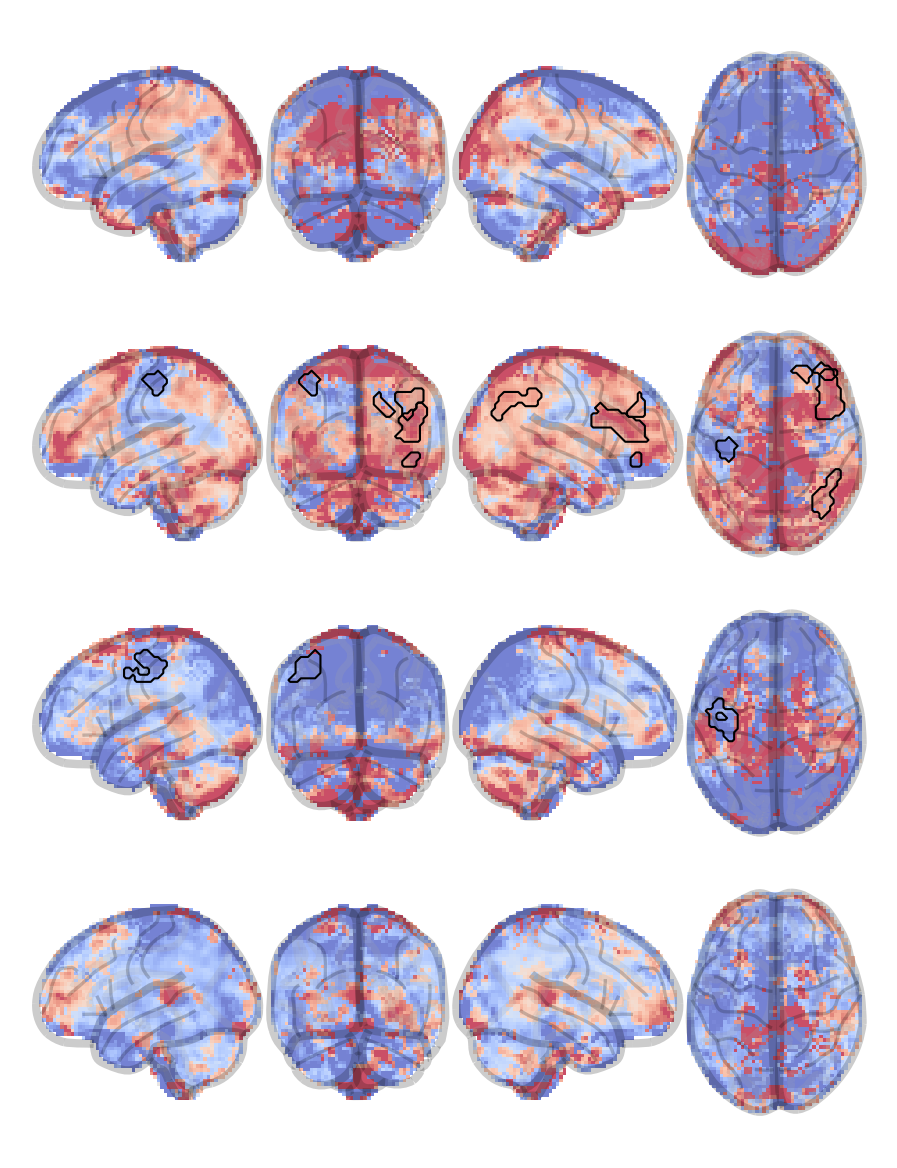

In [11]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_glass_brain, show
from nilearn import image
from nilearn.image import coord_transform
import numpy as np
import os
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# Directories for mod_hi_vs_mod_lo_v7_literature_complex_psc
#base_dir = "/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/effect_maps_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final"
#cluster_dir = "/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/results/mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final"

# Proper pathing for the current Windows Python filesystem setup
base_dir = r"C:\Users\Patrick\Gutbrain_R\results\3dlmer\effect_maps_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates"
cluster_dir = r"C:\Users\Patrick\Gutbrain_R\results\3dlmer\results\mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates"

effect_files = [
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess1.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess2_vs_sess1.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess3_vs_sess1.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess4_vs_sess1.nii.gz"
]
z_files = [
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess1_Z.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess2_vs_sess1_Z.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess3_vs_sess1_Z.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates_sess4_vs_sess1_Z.nii.gz"
]
cluster_files = [
    None,  # sess1 doesn't have a cluster file in the directory
    "sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates.nii.gz",
    "sess3vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_covariates.nii.gz",
    None   # sess4vs1 doesn't have a cluster file in the directory
]
titles = [
    "pre-surgery",
    "4 months post-surgery > pre-surgery",
    "12 months post-surgery > pre-surgery",
    "24 months post-surgery > pre-surgery"
]

sessions_data = []
for i in range(len(effect_files)):
    effect_path = os.path.join(base_dir, effect_files[i])
    z_path = os.path.join(base_dir, z_files[i])
    
    # Handle None cluster files
    if cluster_files[i] is not None:
        cluster_path = os.path.join(cluster_dir, cluster_files[i])
    else:
        cluster_path = None
    
    if not os.path.exists(effect_path):
        print(f"Missing effect file: {effect_path}")
        continue

    effect_img = image.load_img(effect_path)
    effect_data = effect_img.get_fdata()
    affine = effect_img.affine

    # Load Z map if available
    if os.path.exists(z_path):
        z_map = image.load_img(z_path)
        z_data = z_map.get_fdata()
    else:
        z_data = effect_data  # fallback

    # Load cluster map if available, else use zeros
    if cluster_path is not None and os.path.exists(cluster_path):
        cluster_img = image.load_img(cluster_path)
        cluster_data = cluster_img.get_fdata()
    else:
        if cluster_path is None:
            print(f"No cluster file specified for session {i+1}")
        else:
            print(f"Missing cluster file: {cluster_path}")
        cluster_img = effect_img
        cluster_data = np.zeros(effect_data.shape)

    sessions_data.append({
        "effect_img": effect_img,
        "cluster_img": cluster_img,
        "effect_data": effect_data,
        "cluster_data": cluster_data,
        "affine": affine,
        "z_data": z_data
    })

# Color list - all black for contours
color_list = [
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
]

def plot_sessions(sessions_data, cmap='plasma', threshold=0.01, alpha=0.5, vmin=-0.15, vmax=0.15, color_list=color_list, titles=None):
    import matplotlib.gridspec as gridspec
    from nilearn.plotting import plot_glass_brain
    from nilearn.image import coord_transform
    import numpy as np

    if titles is None:
        titles = [f"Session {i+1}" for i in range(len(sessions_data))]
    n_sessions = len(sessions_data)
    fig_width = 3.6
    fig_height = 1.2 * n_sessions  # Removed + 0.5 since no colorbar needed
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300, facecolor='white')
    # Remove colorbar from GridSpec - just use n_sessions rows
    gs = gridspec.GridSpec(n_sessions, 1, hspace=0.03)

    for i, session in enumerate(sessions_data):
        ax = plt.subplot(gs[i])
        #ax.text(-0.13, 0.5, chr(65 + i), transform=ax.transAxes, fontsize=8, fontweight='bold', va='center', ha='center')
        effect_img = session["effect_img"]
        cluster_img = session["cluster_img"]
        effect_data = session["effect_data"]
        cluster_data = session["cluster_data"]
        affine = session["affine"]
        z_data = session["z_data"]

        labels = [l for l in np.unique(cluster_data) if l != 0]

        display = plot_glass_brain(
            effect_img,
            display_mode='lyrz',
            colorbar=False,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            threshold=threshold,
            alpha=alpha,
            axes=ax,
            plot_abs=False,
            black_bg=False,
            annotate=False
        )
        display.bg_color = (1, 1, 1, 1)
        display.frameon = False
        display.draw_cross = False

        if labels:
            for idx, label in enumerate(labels):
                mask = (cluster_data == label).astype(float)
                mask_img = image.new_img_like(cluster_img, mask)
                # All contours in black
                display.add_contours(mask_img, colors=["#000000"], linewidths=0.5, levels=[0.5])
                
                z_vals = z_data[cluster_data == label]
                effect_vals = effect_data[cluster_data == label]
                peak_z = np.max(np.abs(z_vals))
                mean_es = np.mean(effect_vals)
                abs_z = np.abs(z_data)
                cluster_mask = (cluster_data == label)
                masked_z = abs_z * cluster_mask
                if np.any(masked_z):
                    peak_idx_flat = np.argmax(masked_z)
                    peak_idx = np.unravel_index(peak_idx_flat, z_data.shape)
                    mni_coords = coord_transform(peak_idx[0], peak_idx[1], peak_idx[2], affine)
                    mni_str = f"{mni_coords[0]:.1f}, {mni_coords[1]:.1f}, {mni_coords[2]:.1f}"
                else:
                    mni_str = "n/a"
                
                print(f"Session: {titles[i]}, Cluster {int(label)}: PeakZ={peak_z:.2f}, MNI=[{mni_str}], Mean ES={mean_es:.2f}%")

    # Removed all colorbar creation code
    plt.tight_layout()
    plt.savefig('glass_brain_Hi_vs_Lo_vertical.png', dpi=300, bbox_inches='tight', facecolor='white')
    return fig

# Get the original coolwarm colormap
base_cmap = plt.colormaps.get_cmap('coolwarm')

def transparent_cmap(cmap, alpha=0.5):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha
    return mcolors.ListedColormap(colors, name=f"{cmap.name}_alpha{int(alpha*100)}")

coolwarm_transparent = transparent_cmap(base_cmap, alpha=0.7)

# Plot
fig = plot_sessions(
    sessions_data,
    cmap=coolwarm_transparent,
    threshold=1e-6,
    alpha=0.2,
    vmin=-0.15,
    vmax=0.15,
    color_list=color_list,
    titles=titles
)

## view Hi vs view Lo

Missing cluster file: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/results/view_Hi_vs_view_low_v7_literature_complex_psc_qc_final/sess3vs1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz
Missing cluster file: /home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/results/view_Hi_vs_view_low_v7_literature_complex_psc_qc_final/sess4vs1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz

DIAGNOSTIC: Checking cluster files

=== Session 1 (pre-surgery) ===
Z-map shape: (53, 65, 56)
Z-map affine:
[[   3.   -0.   -0.  -78.]
 [  -0.    3.   -0. -114.]
 [   0.    0.    3.  -78.]
 [   0.    0.    0.    1.]]
Z-map range: -4.36 to 5.78
Voxels with |Z| > 3.29: 616
Cluster map shape: (53, 65, 56)
Cluster map affine:
[[   3.   -0.   -0.  -78.]
 [  -0.    3.   -0. -114.]
 [   0.    0.    3.  -78.]
 [   0.    0.    0.    1.]]
Unique cluster labels: [0. 1. 2.]
  Cluster 1: 305 voxels, Z range: 3.29 to 5.78, Peak |

/tmp/ipykernel_1426584/1259856128.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


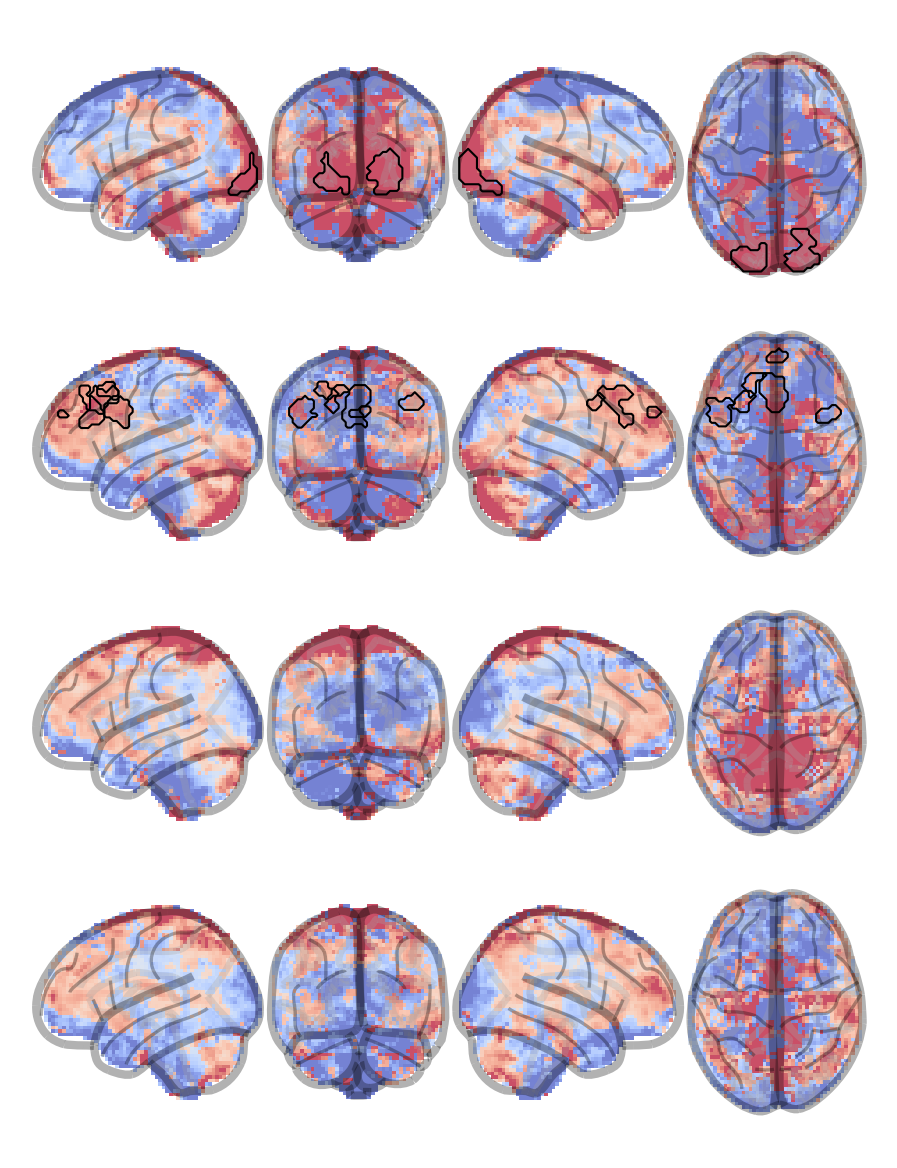

In [24]:
# Directories for view_Hi_vs_view_low_v7_literature_complex_psc_qc_final
base_dir = "/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/effect_maps_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final"
cluster_dir = "/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/results/view_Hi_vs_view_low_v7_literature_complex_psc_qc_final"

effect_files = [
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess1.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess2_vs_sess1.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess3_vs_sess1.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess4_vs_sess1.nii.gz"
]
z_files = [
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess1_Z.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess2_vs_sess1_Z.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess3_vs_sess1_Z.nii.gz",
    "view_Hi_vs_view_low_v7_literature_complex_psc_qc_final_sess4_vs_sess1_Z.nii.gz"
]
cluster_files = [
    "sess1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz",
    "sess2vs1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz",
    "sess3vs1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz",
    "sess4vs1_clustered_p001_ACF_residuals_view_Hi_vs_view_low_v7_literature_complex_psc_qc_final.nii.gz"
]
titles = [
    "pre-surgery",
    "4 months post-surgery > pre-surgery",
    "12 months post-surgery > pre-surgery",
    "24 months post-surgery > pre-surgery"
]

sessions_data = []
for i in range(len(effect_files)):
    effect_path = os.path.join(base_dir, effect_files[i])
    z_path = os.path.join(base_dir, z_files[i])
    cluster_path = os.path.join(cluster_dir, cluster_files[i])
    
    if not os.path.exists(effect_path):
        print(f"Missing effect file: {effect_path}")
        continue

    effect_img = image.load_img(effect_path)
    effect_data = effect_img.get_fdata()
    affine = effect_img.affine

    # Load Z map if available
    if os.path.exists(z_path):
        z_map = image.load_img(z_path)
        z_data = z_map.get_fdata()
    else:
        z_data = effect_data  # fallback

    # Load cluster map if available, else use zeros
    if os.path.exists(cluster_path):
        cluster_img = image.load_img(cluster_path)
        cluster_data = cluster_img.get_fdata()
    else:
        print(f"Missing cluster file: {cluster_path}")
        cluster_img = effect_img
        cluster_data = np.zeros(effect_data.shape)

    sessions_data.append({
        "effect_img": effect_img,
        "cluster_img": cluster_img,
        "effect_data": effect_data,
        "cluster_data": cluster_data,
        "affine": affine,
        "z_data": z_data
    })

# Add this diagnostic code right after loading the sessions_data (around line 5843)

print("\n" + "="*60)
print("DIAGNOSTIC: Checking cluster files")
print("="*60)

z_threshold = 3.29

for i, session in enumerate(sessions_data):
    print(f"\n=== Session {i+1} ({titles[i]}) ===")
    
    z_data = session["z_data"]
    cluster_data = session["cluster_data"]
    
    # Check Z-map
    print(f"Z-map shape: {z_data.shape}")
    print(f"Z-map affine:\n{session['affine']}")
    print(f"Z-map range: {np.min(z_data):.2f} to {np.max(z_data):.2f}")
    print(f"Voxels with |Z| > {z_threshold}: {np.sum(np.abs(z_data) > z_threshold)}")
    
    # Check cluster map
    print(f"Cluster map shape: {cluster_data.shape}")
    print(f"Cluster map affine:\n{session['cluster_img'].affine}")
    unique_labels = np.unique(cluster_data)
    print(f"Unique cluster labels: {unique_labels}")
    
    # For each cluster, report its peak Z and range
    for label in unique_labels:
        if label == 0:
            continue
        mask = (cluster_data == label)
        z_in_cluster = z_data[mask]
        abs_z_in_cluster = np.abs(z_in_cluster)
        n_vox = np.sum(mask)
        z_range = f"{np.min(z_in_cluster):.2f} to {np.max(z_in_cluster):.2f}"
        peak_abs_z = np.max(abs_z_in_cluster)
        print(f"  Cluster {int(label)}: {n_vox} voxels, Z range: {z_range}, Peak |Z|: {peak_abs_z:.2f}")

print("\n" + "="*60)

# Color list - all black for contours
color_list = [
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
    "#000000",  # black
]

def plot_sessions(sessions_data, cmap='plasma', threshold=0.01, alpha=0.5, vmin=-0.15, vmax=0.15, color_list=color_list, titles=None):
    import matplotlib.gridspec as gridspec
    from nilearn.plotting import plot_glass_brain
    from nilearn.image import coord_transform
    import numpy as np

    if titles is None:
        titles = [f"Session {i+1}" for i in range(len(sessions_data))]
    n_sessions = len(sessions_data)
    fig_width = 3.6
    fig_height = 1.2 * n_sessions
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=300, facecolor='white')
    gs = gridspec.GridSpec(n_sessions, 1, hspace=0.03)

    for i, session in enumerate(sessions_data):
        ax = plt.subplot(gs[i])
        # Remove or comment out this line to remove panel labels:
        # ax.text(-0.13, 0.5, chr(65 + i), transform=ax.transAxes, fontsize=8, fontweight='bold', va='center', ha='center')
        
        effect_img = session["effect_img"]
        cluster_img = session["cluster_img"]
        effect_data = session["effect_data"]
        cluster_data = session["cluster_data"]
        affine = session["affine"]
        z_data = session["z_data"]

        labels = [l for l in np.unique(cluster_data) if l != 0]

        display = plot_glass_brain(
            effect_img,
            display_mode='lyrz',
            colorbar=False,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            threshold=threshold,
            alpha=alpha,
            axes=ax,
            plot_abs=False,
            black_bg=False,
            annotate=False
        )
        display.bg_color = (1, 1, 1, 1)
        display.frameon = False
        display.draw_cross = False

        if labels:
            for idx, label in enumerate(labels):
                mask = (cluster_data == label).astype(float)
                mask_img = image.new_img_like(cluster_img, mask)
                display.add_contours(mask_img, colors=["#000000"], linewidths=0.5, levels=[0.5])
                
                z_vals = z_data[cluster_data == label]
                effect_vals = effect_data[cluster_data == label]
                peak_z = np.max(np.abs(z_vals))
                mean_es = np.mean(effect_vals)
                abs_z = np.abs(z_data)
                cluster_mask = (cluster_data == label)
                masked_z = abs_z * cluster_mask
                if np.any(masked_z):
                    peak_idx_flat = np.argmax(masked_z)
                    peak_idx = np.unravel_index(peak_idx_flat, z_data.shape)
                    mni_coords = coord_transform(peak_idx[0], peak_idx[1], peak_idx[2], affine)
                    mni_str = f"{mni_coords[0]:.1f}, {mni_coords[1]:.1f}, {mni_coords[2]:.1f}"
                else:
                    mni_str = "n/a"
                
                print(f"Session: {titles[i]}, Cluster {int(label)}: PeakZ={peak_z:.2f}, MNI=[{mni_str}], Mean ES={mean_es:.2f}%")

    plt.tight_layout()
    plt.savefig('glass_brain_Hi_vs_Lo_vertical.png', dpi=300, bbox_inches='tight', facecolor='white')
    return fig

# Get the original coolwarm colormap
base_cmap = plt.colormaps.get_cmap('coolwarm')

def transparent_cmap(cmap, alpha=0.5):
    colors = cmap(np.linspace(0, 1, cmap.N))
    colors[:, -1] = alpha
    return mcolors.ListedColormap(colors, name=f"{cmap.name}_alpha{int(alpha*100)}")

coolwarm_transparent = transparent_cmap(base_cmap, alpha=0.7)

# Plot
fig = plot_sessions(
    sessions_data,
    cmap=coolwarm_transparent,
    threshold=1e-6,
    alpha=0.3,
    vmin=-0.15,
    vmax=0.15,
    color_list=color_list,
    titles=titles
)

# TWL model with final QC

## mod hi vs mod lo format adjusted

C:\Users\Patrick\AppData\Local\Temp\ipykernel_22884\2279717789.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('coolwarm')
C:\Users\Patrick\AppData\Local\Temp\ipykernel_22884\2279717789.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


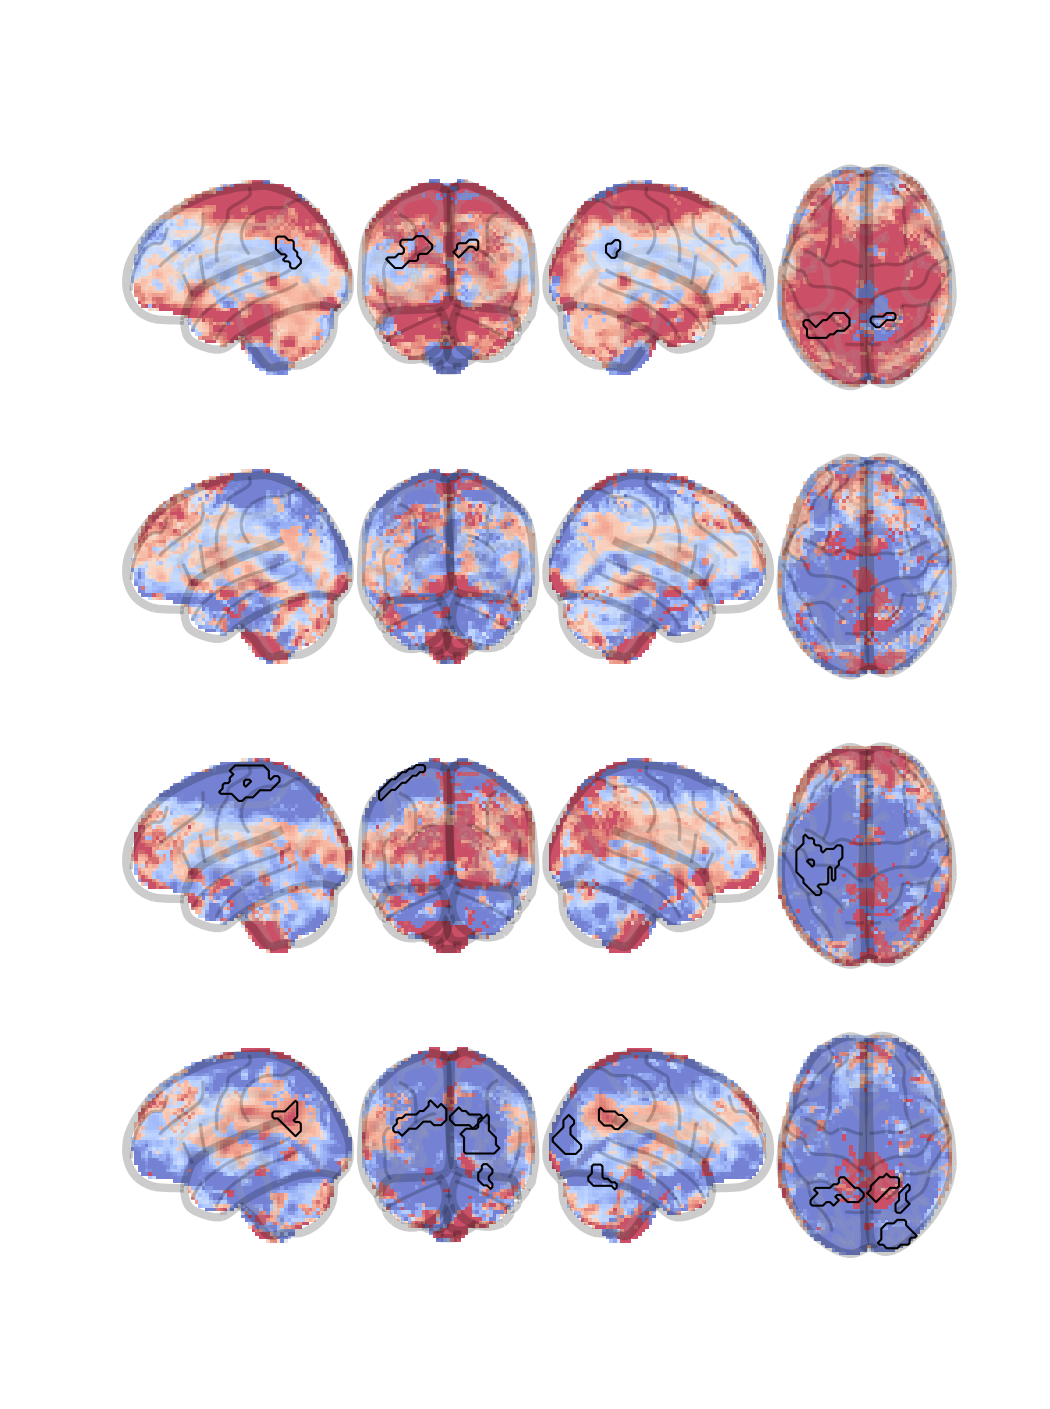

In [8]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_glass_brain
from nilearn import image
import numpy as np
import os
import matplotlib.colors as mcolors

# Directories - cluster dir now has _covar suffix
base_dir = "/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/effect_maps_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar"
cluster_dir = "/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/results/mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar"

effect_files = [
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar_sess1_x_twl24.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar_sess2_vs_sess1_x_twl24.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar_sess3_vs_sess1_x_twl24.nii.gz",
    "mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final_covar_sess4_vs_sess1_x_twl24.nii.gz"
]

# Updated cluster filenames - they're simpler and don't have the full prefix
cluster_files = [
    "sess1_x_twl24_clustered.nii.gz",
    None,  # sess2vs1 doesn't exist
    "sess3vs1_x_twl24_clustered.nii.gz",
    "sess4vs1_x_twl24_clustered.nii.gz"
]



# Create transparent coolwarm colormap
base_cmap = plt.cm.get_cmap('coolwarm')
colors = base_cmap(np.linspace(0, 1, base_cmap.N))
colors[:, -1] = 0.7
coolwarm_transparent = mcolors.ListedColormap(colors)

# Create figure with 4 subplots (4x1 layout - one below the other)
fig = plt.figure(figsize=(3.6, 4.8), dpi=300, facecolor='white')

for idx, (effect_file, cluster_file, title) in enumerate(zip(effect_files, cluster_files, titles)):
    effect_path = os.path.join(base_dir, effect_file)
    
    # Load effect map
    effect_img = image.load_img(effect_path)
    effect_data = effect_img.get_fdata()
    effect_data = effect_data / 10.0
    effect_img = image.new_img_like(effect_img, effect_data)
    
    # Load cluster map if exists
    if cluster_file is not None:
        cluster_path = os.path.join(cluster_dir, cluster_file)
        if os.path.exists(cluster_path):
            cluster_img = image.load_img(cluster_path)
            cluster_data = cluster_img.get_fdata()
        else:
            cluster_data = np.zeros(effect_data.shape)
    else:
        cluster_data = np.zeros(effect_data.shape)
    
    # Create subplot - 4 rows, 1 column
    ax = fig.add_subplot(4, 1, idx + 1)
    
    # Plot glass brain
    display = plot_glass_brain(
        effect_img,
        display_mode='lyrz',
        colorbar=False,
        cmap=coolwarm_transparent,
        vmin=-0.2,
        vmax=0.2,
        threshold=1e-6,
        alpha=0.2,
        plot_abs=False,
        black_bg=False,
        annotate=False,
        axes=ax
    )
    
    display.bg_color = (1, 1, 1, 1)
    display.frameon = False
    display.draw_cross = False
    
    # Add cluster contours
    labels = [l for l in np.unique(cluster_data) if l != 0]
    if labels:
        for label in labels:
            mask = (cluster_data == label).astype(float)
            mask_img = image.new_img_like(effect_img, mask)
            display.add_contours(mask_img, colors=["#000000"], linewidths=0.5, levels=[0.5])
    
    #ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig('glass_brain_all_sessions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()